# Spectral Binning

TauREx forward models produce spectra on a very fine native wavenumber grid — typically tens of thousands of points. Observed spectra, by contrast, rarely have more than a few hundred bins. Before comparing model to data (or just for clearer plots), the model spectrum needs to be resampled down to a coarser grid. That is the focus of this notebook, and the same technique appears directly in the retrieval setup of notebook 10.

Three binners are available:
- **`SimpleBinner`** — fast nearest-neighbour binning onto any wavenumber array.
- **`FluxBinner`** — flux-conserving binning, automatically selected when binning to an observed spectrum.
- **`NativeBinner`** — a pass-through that preserves the native resolution.

More information about binning options is [here](../user/taurex/binning.rst), observed spectra are [here](../user/taurex/observation.rst), and instrument models are [here](../user/taurex/instrument.rst).

## Data Note

This notebook uses the opacity and CIA files set up in notebook 1. TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com) and [HITRAN](https://hitran.org/).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from _shared import build_transmission_model
from taurex.cia.hitrancia import EndOfHitranCIAError, HitranCIA

if not getattr(HitranCIA, "_notebook_header_patch", False):
    _original_init = HitranCIA.__init__

    def _patched_init(self, filename):
        _original_init(self, filename)
        self._pair_name = Path(filename).stem.split("_")[0]

    def _patched_read_header(self, f):
        line = f.readline()
        if line is None or line == "":
            raise EndOfHitranCIAError

        split = line.split()
        for index in range(len(split) - 4):
            try:
                start_wn = float(split[index])
                end_wn = float(split[index + 1])
                total_points_float = float(split[index + 2])
                temperature = float(split[index + 3])
                max_cia = float(split[index + 4])
            except ValueError:
                continue

            if total_points_float.is_integer():
                return start_wn, end_wn, int(total_points_float), temperature, max_cia

        raise ValueError(f"Could not parse HITRAN CIA header: {line.strip()}")

    HitranCIA.__init__ = _patched_init
    HitranCIA.read_header = _patched_read_header
    HitranCIA._notebook_header_patch = True

context = build_transmission_model(include_cia=True, include_rayleigh=True, download=False)
tm = context['tm']

print('Model ready with contributions:', [c.name for c in tm.contribution_list])

Model ready with contributions: ['Absorption', 'CIA', 'Rayleigh']


## The Native Grid

The raw output of `model()` is on TauREx's internal wavenumber grid — fine enough to resolve narrow molecular lines but impractical to plot directly or compare to an observation. The cells below resample it to more manageable resolutions.

In [2]:
native_wn, native_rprs, _, _ = tm.model()
native_wl = 10000 / native_wn[::-1]
native_rprs = native_rprs[::-1]

print(f'Native grid: {len(native_wn)} points')
print(f'Wavelength range: {native_wl.min():.3f} to {native_wl.max():.3f} um')

Native grid: 76744 points
Wavelength range: 0.300 to 50.002 um


## SimpleBinner

`SimpleBinner` takes any user-supplied wavenumber array and maps the native spectrum onto it using nearest-neighbour assignment. It is the fastest option and works well when bin widths are small relative to the spectral features.

The `bin_model` call accepts the raw tuple returned by `model()`, so no unpacking is needed beforehand. Equivalent parameter-file options are documented [here](../user/taurex/binning.rst).

In [3]:
from taurex.binning import SimpleBinner

# Create a logarithmic wavelength grid (0.4 - 12 um), convert to wavenumber
bin_wl = np.logspace(np.log10(0.4), np.log10(12.0), 300)
bin_wn = np.sort(10000 / bin_wl)

binner = SimpleBinner(wngrid=bin_wn)
binned_wn, binned_rprs, _, _ = binner.bin_model(tm.model(wngrid=bin_wn))
binned_wl = 10000 / binned_wn[::-1]
binned_rprs = binned_rprs[::-1]

print(f'Binned grid: {len(binned_wn)} points')

Binned grid: 300 points


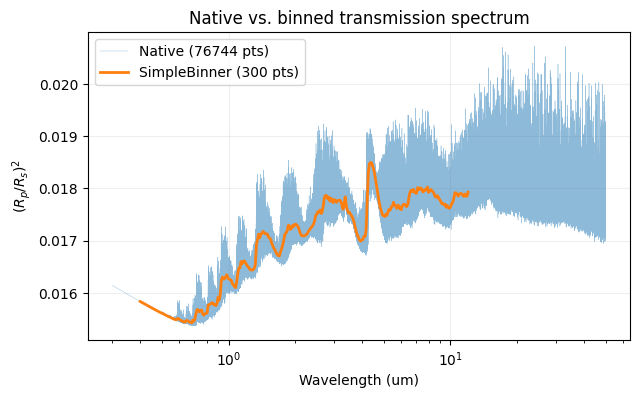

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(native_wl, native_rprs, lw=0.3, alpha=0.5, label=f'Native ({len(native_wl)} pts)')
plt.plot(binned_wl, binned_rprs, lw=2, label=f'SimpleBinner ({len(binned_wl)} pts)')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('Native vs. binned transmission spectrum')
plt.legend()
plt.grid(alpha=0.2)

## FluxBinner

`FluxBinner` integrates the spectrum over each output bin rather than sampling the nearest point. The result is more accurate than `SimpleBinner` when bin widths are comparable to or larger than the spectral features — which is typical for medium- and low-resolution instruments.

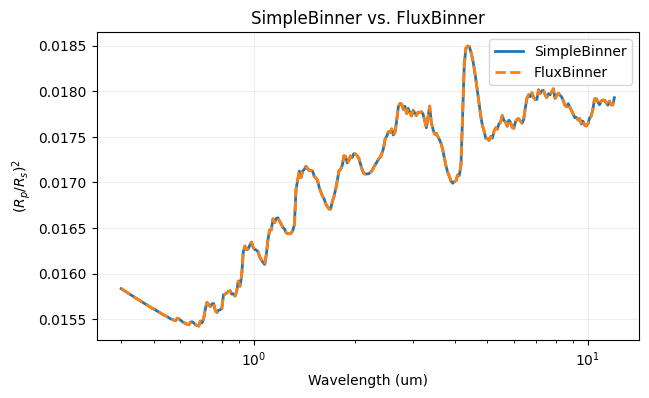

In [5]:
from taurex.binning import FluxBinner

flux_binner = FluxBinner(wngrid=bin_wn)
fb_wn, fb_rprs, _, _ = flux_binner.bin_model(tm.model(wngrid=bin_wn))
fb_wl = 10000 / fb_wn[::-1]
fb_rprs = fb_rprs[::-1]

plt.figure(figsize=(7, 4))
plt.plot(binned_wl, binned_rprs, lw=2, label='SimpleBinner')
plt.plot(fb_wl, fb_rprs, lw=2, ls='--', label='FluxBinner')
plt.xscale('log')
plt.xlabel('Wavelength (um)')
plt.ylabel('$(R_p/R_s)^2$')
plt.title('SimpleBinner vs. FluxBinner')
plt.legend()
plt.grid(alpha=0.2)

## Binning to Real Data

When the model must be compared to an actual observation, `ObservedSpectrum.create_binner()` returns a `FluxBinner` pre-aligned to the observation's wavelength grid. This guarantees the model and data are evaluated at exactly the same bin centres — no manual grid matching needed.

More information about observations is [here](../user/taurex/observation.rst), binning options are [here](../user/taurex/binning.rst), and instrument models are [here](../user/taurex/instrument.rst). The next notebook uses this pattern in a full retrieval.

```python
from taurex.data.spectrum.observed import ObservedSpectrum

obs = ObservedSpectrum('observation.dat')
obs_binner = obs.create_binner()
binned_wn, binned_rprs, _, _ = obs_binner.bin_model(tm.model(obs.wavenumberGrid))
```

The observation file is plain text with 3–4 columns: wavelength (μm), spectral data, uncertainty, and optionally bin width.